# Packages

In [1]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 

In [2]:
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf

# Costs

In [3]:
# PyPSA Costs
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)


costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]
os.getcwd()
os.chdir("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive")
os.getcwd()

'C:\\Users\\Pulin\\Desktop\\Msc_Thesis_Greenlab_Skive'

# Weather Data

In [4]:
# Weather Data
# 1. Load the dataset
PV_data = pd.read_csv("Re_Ninja_PV_data_DK.csv", 
    skiprows=3, sep=None, engine='python',
    compression='infer')
# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)
# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)
# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()
# Display the first few rows to verify
#print(PV_data.head())
CF_solar = PV_data.mean(axis = 1) # average all the years
OnshoreWind_Data = pd.read_csv("Re_Ninja_WindOnshore_data_DK.csv",
    skiprows=3, sep=None, engine='python',
    compression='infer')

OnshoreWind_Data["time"] = pd.to_datetime(OnshoreWind_Data["time"]).dt.tz_localize(None)
OnshoreWind_Data.index = pd.DatetimeIndex(OnshoreWind_Data["time"])
OnshoreWind_Data.drop(columns = ["time"], inplace = True)
OnshoreWind_Data.columns = OnshoreWind_Data.columns.str.strip()

CF_wind = OnshoreWind_Data.mean(axis = 1) # average of all years for the different datasets
CF_wind["2021"]


time
2021-01-01 00:00:00    0.088753
2021-01-01 01:00:00    0.080665
2021-01-01 02:00:00    0.071514
2021-01-01 03:00:00    0.061485
2021-01-01 04:00:00    0.052379
                         ...   
2021-12-31 19:00:00    0.267740
2021-12-31 20:00:00    0.269965
2021-12-31 21:00:00    0.280798
2021-12-31 22:00:00    0.309923
2021-12-31 23:00:00    0.334850
Length: 8760, dtype: float64

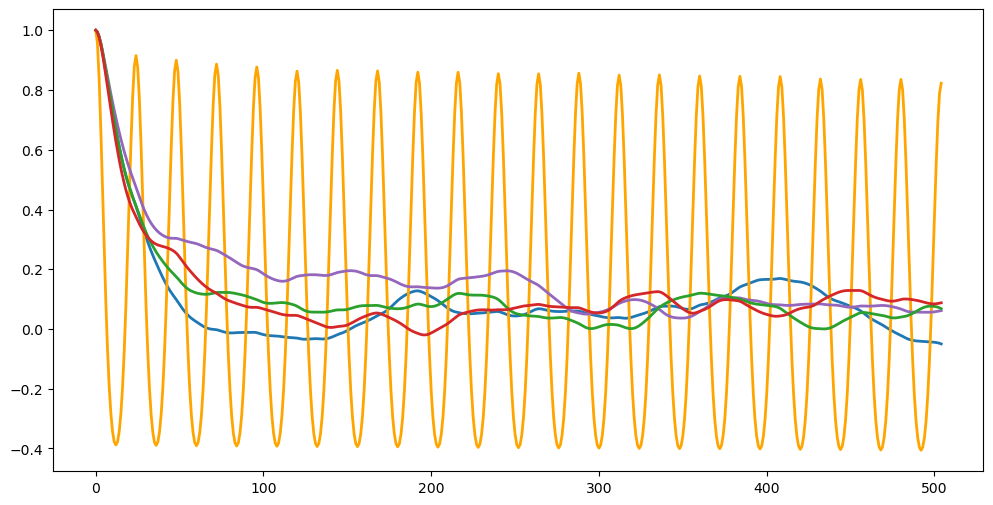

In [5]:

# 1. Calculate the ACF values for a week (168 hours)
nlags = 24*7*3
acf_wind21 = acf(CF_wind["2021"], nlags=nlags)
acf_solar21 = acf(CF_solar["2021"], nlags=nlags)
acf_wind22 = acf(CF_wind["2022"], nlags=nlags)
acf_wind23 = acf(CF_wind["2023"], nlags=nlags)
acf_wind24 = acf(CF_wind["2024"], nlags=nlags)
#acf_solar22 = acf(CF_solar["2022"], nlags=nlags)
# 2. Plot using plt.plot() for clarity over long durations
plt.figure(figsize=(12, 6))
# Plot wind in blue and solar in orange
plt.plot(range(len(acf_wind21)), acf_wind21, label='Wind ($CF_{wind}$) 2021', color='tab:blue', linewidth=2)
plt.plot(range(len(acf_solar21)), acf_solar21, label='Solar ($CF_{solar}$)', color='orange', linewidth=2)
plt.plot(range(len(acf_wind22)), acf_wind22, label='Wind ($CF_{wind}$) 2022', color='tab:purple', linewidth=2)
plt.plot(range(len(acf_wind23)), acf_wind23, label='Wind ($CF_{wind}$) 2023', color='tab:green', linewidth=2)
plt.plot(range(len(acf_wind24)), acf_wind24, label='Wind ($CF_{wind}$) 2024', color='tab:red', linewidth=2)
#plt.plot(range(len(acf_solar22)), acf_solar22, label='Solar ($CF_{solar}$)', color='red', linewidth=2)



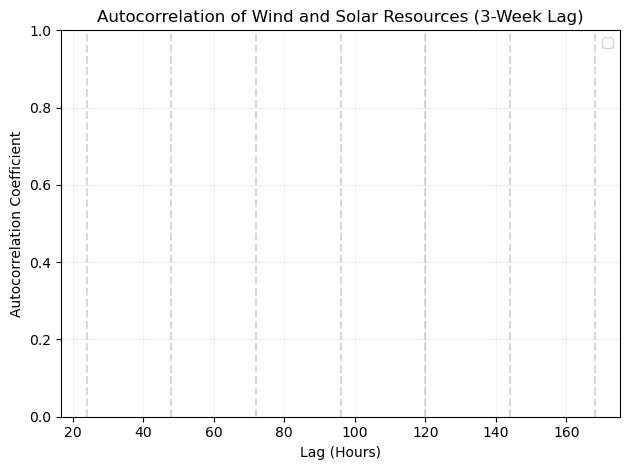

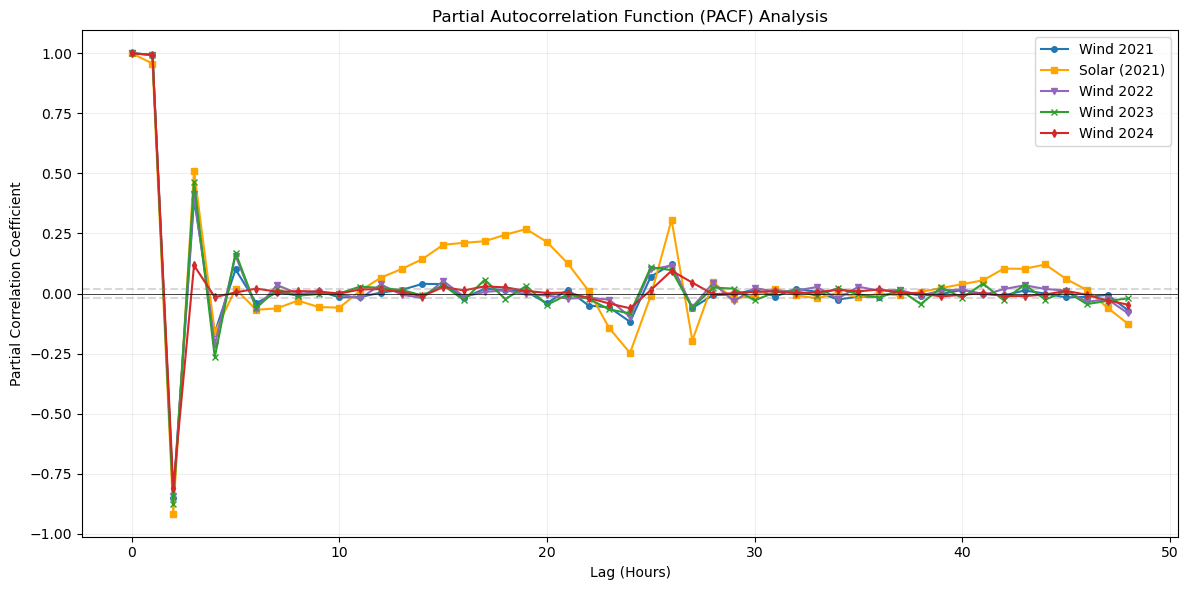

In [6]:

# 3. Add vertical dashed lines at 24-hour intervals to highlight the cycle
for day in range(1, 8):
    plt.axvline(x=day*24, color='gray', linestyle='--', alpha=0.3)

# Formatting for your thesis
plt.title("Autocorrelation of Wind and Solar Resources (3-Week Lag)")
plt.xlabel("Lag (Hours)")
plt.ylabel("Autocorrelation Coefficient")
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# 1. Calculate the PACF values (use 48h to see the AR order clearly)
nlags_pacf = 48
pacf_wind21 = pacf(CF_wind["2021"], nlags=nlags_pacf)
pacf_solar21 = pacf(CF_solar["2021"], nlags=nlags_pacf)
pacf_wind22 = pacf(CF_wind["2022"], nlags=nlags_pacf)
pacf_wind23 = pacf(CF_wind["2023"], nlags=nlags_pacf)
pacf_wind24 = pacf(CF_wind["2024"], nlags=nlags_pacf)

# 2. Plotting
plt.figure(figsize=(12, 6))
# Plot wind series and the solar comparison
plt.plot(range(len(pacf_wind21)), pacf_wind21, label='Wind 2021', color='tab:blue', marker='o', markersize=4)
plt.plot(range(len(pacf_solar21)), pacf_solar21, label='Solar (2021)', color='orange', marker='s', markersize=4)
plt.plot(range(len(pacf_wind22)), pacf_wind22, label='Wind 2022', color='tab:purple', marker='v', markersize=4)
plt.plot(range(len(pacf_wind23)), pacf_wind23, label='Wind 2023', color='tab:green', marker='x', markersize=4)
plt.plot(range(len(pacf_wind24)), pacf_wind24, label='Wind 2024', color='tab:red', marker='d', markersize=4)
# 3. Add confidence intervals (critical for PACF)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
# Significance level approximately 1.96/sqrt(N)
plt.axhline(y=0.02, color='gray', linestyle='--', alpha=0.3)
plt.axhline(y=-0.02, color='gray', linestyle='--', alpha=0.3)
plt.title("Partial Autocorrelation Function (PACF) Analysis")
plt.xlabel("Lag (Hours)")
plt.ylabel("Partial Correlation Coefficient")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


# NG Prices

In [7]:
## NG Prices
current_dir = os.getcwd()
gas_file = os.path.join(current_dir, 'GasDailyBalancingPrice.xlsx')

# units is in DKK/kWh
gas_price_pre_oct_2021 = pd.read_excel("GasSystemBalanceUntil20221001.xlsx")
# 1. Clean and Deduplicate as you did
gas_price_pre_oct_2021["GasDay"] = pd.to_datetime(gas_price_pre_oct_2021["GasDay"]).dt.tz_localize(None)
gas_price_pre_oct_2021.index = pd.DatetimeIndex(gas_price_pre_oct_2021["GasDay"])
gas_price_pre_oct_2021 = gas_price_pre_oct_2021.groupby(level=0).mean(numeric_only=True)

# 2. Add a "dummy" row to ensure the LAST day gets all 24 hours
# This adds one more day at the very end of your existing index
last_day = gas_price_pre_oct_2021.index.max()
next_day = last_day + pd.Timedelta(days=1)
gas_price_pre_oct_2021.loc[next_day] = None 

# 3. Apply the 6-hour offset for the Danish Gas Day
gas_price_pre_oct_2021.index = gas_price_pre_oct_2021.index + pd.Timedelta(hours=6)

# 4. Resample and Forward Fill
# This propagates the 06:00 price through all 24 hours of that gas day
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021.resample('h').ffill()

# 5. Drop the very last hour (which belongs to the dummy day's 06:00 start)
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021_hourly.iloc[:-1]
gas_price_data = pd.read_excel(gas_file)

# 1. Convert the 'GasDay' column to datetime and remove timezone offset
gas_price_data["GasDay"] = pd.to_datetime(gas_price_data["GasDay"]).dt.tz_localize(None)
# 2. Set the 'GasDay' column as the index
gas_price_data.index = pd.DatetimeIndex(gas_price_data["GasDay"])
# 3. Resample to hourly to match solar_pv_data (forward fill daily prices)
gas_price_hourly = gas_price_data.resample('h').ffill()
# EURO -> DKK exchange rate
EUR_DKK_exchangerate = (gas_price_hourly["ExchangeRateEUR_DKK"]/100)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] = ((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchangerate)*1000)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]
part1 = gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"][:"2022-09-30"]*(1000/7.45)  # DKK/kwh -> EUR/MWh
part2 = gas_price_hourly["MarginalPurchasePriceEUR_MWh"] # EUR/MWh

NG_price = pd.concat([part1, part2], axis=1)

# keep='last' prioritizes data from 'part2' for the overlapping hours
NG_price = NG_price[~NG_price.index.duplicated(keep='last')].sort_index()

# 4. Fill any remaining tiny gaps (just in case)
NG_price = NG_price.resample('H').ffill()

# 1. Fill missing values in the EUR_MWh column with the DKK column values
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].fillna(NG_price["GasBuyingPriceDKK"])

# 2. Drop the original DKK column if you no longer need it
NG_price = NG_price.drop(columns=["GasBuyingPriceDKK"])
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].ffill() 

# Electrcity Prices

In [8]:
# Electrcity Prices
"full spot price data el DK1";
elspotprices = pd.read_excel("Elspotprices1999_onwards.xlsx", index_col=0, parse_dates=True) # EUR/MWh
"øre/kWh";
tariff_el_use = {
    "2021": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.123)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.09,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.92         # Net Tariff: Spidslast
    },
     "2022": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.116)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 4.51,         # Net Tariff: Lavlast
        "el_tariff_high": 8.32,        # Net Tariff: Højlast
        "el_tariff_peak": 12.15         # Net Tariff: Spidslast
    },
    "2023": {
        "el_transmission_tariff": 5.8,
        "el_system_tariff": 5.4,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.16)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.43,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.33         # Net Tariff: Spidslast
    },
    "2024": {
        "el_transmission_tariff": 7.4,
        "el_system_tariff": 5.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.24)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 0.85,         # Net Tariff: Lavlast
        "el_tariff_high": 2.54,        # Net Tariff: Højlast
        "el_tariff_peak": 5.08,         # Net Tariff: Spidslast
    }

}


In [9]:

def build_electricity_grid_price_w_tariff(Elspotprices, tariff_dict, year):
    """
    Inputs:
        Elspotprices : pd.DataFrame (containing 'SpotPriceEUR')
        tariff_dict  : The multi-year dictionary (tariff_el_use)
        year         : int or str (e.g., 2021)
    """
    year_str = str(year)
    
    # --- 1. PREVENT TYPE ERROR: Select only the numeric column and filter year ---
    # We select only the 'SpotPriceEUR' column to avoid adding fees to string columns
    spot = Elspotprices.loc[Elspotprices.index.year == int(year_str), "SpotPriceEUR"]
    
    # Ensure it's numeric (handles any strange characters in the Excel)
    spot = pd.to_numeric(spot, errors='coerce').dropna()
    
    # --- 2. GET TARIFFS ---
    d = tariff_dict[year_str]
    DKK_to_EUR_MWh = 10 / 7.45  # Conversion: (øre/kWh * 10) / exchange_rate
    
    hours = spot.index
    is_winter = hours.month.isin([1, 2, 3, 10, 11, 12])
    is_weekday = hours.weekday < 5 
    
    # Define Hour Brackets
    is_low_hr  = hours.hour.isin(range(0, 6))   # 00:00 - 05:59
    is_peak_hr = hours.hour.isin(range(17, 21)) # 17:00 - 20:59
    is_day_hr  = hours.hour.isin(range(6, 24))  # 06:00 - 23:59

    # --- 3. APPLY NET TARIFF LOGIC (N1 MODEL 3.0) ---
    # Baseline is Low
    net_tariff = pd.Series(d["el_tariff_low"], index=hours)
    
    # Apply High (Højlast) to all hours between 06:00 and 00:00
    net_tariff.loc[is_day_hr] = d["el_tariff_high"]
    
    # Apply Peak (Spidslast) ONLY in Winter AND on Weekdays during Peak Hours
    net_tariff.loc[is_winter & is_weekday & is_peak_hr] = d["el_tariff_peak"]

    # --- 4. CALCULATE FINAL PRICES ---
    fixed_fees_ore = d["el_transmission_tariff"] + d["el_system_tariff"] + d["el_tax"]
    
    # Buy Price = Spot + (Fixed Tariffs + DSO Net Tariff) converted to EUR/MWh
    buy_price = spot + (fixed_fees_ore + net_tariff) * DKK_to_EUR_MWh
    
    # Sell Price = Spot minus production/balancing fees
    sell_price = -spot + (d["el_prod_tariff"] * DKK_to_EUR_MWh)

    return buy_price, sell_price

import_price21, export_price21 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2021")
import_price22, export_price22 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2022")
import_price23, export_price23 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2023")
import_price24, export_price24 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2024")


<Axes: xlabel='HourUTC'>

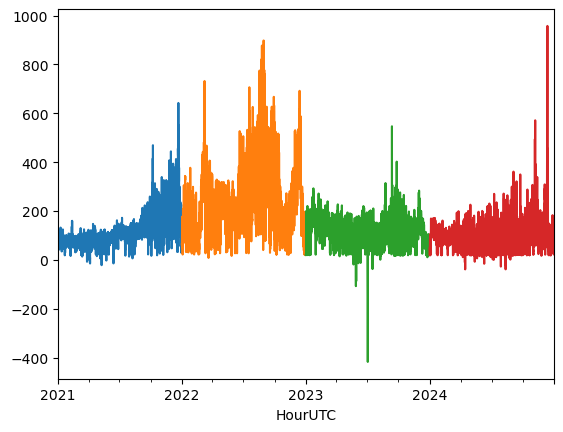

In [10]:

import_price21.plot()
import_price22.plot()
import_price23.plot()
import_price24.plot()

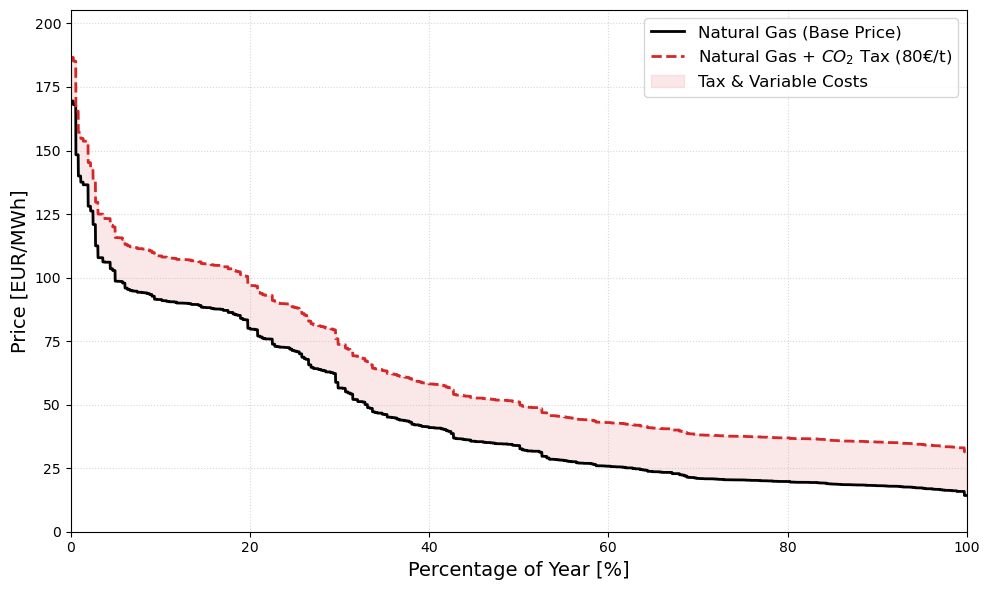

In [12]:

# 1. Setup Data
base_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2021"].sort_values(ascending=False).values
# 0.202 = Emission Factor (tCO2/MWh), 80 = Carbon Price (EUR/t), 1.007 = Additional variable cost
taxed_price = (NG_price["MarginalPurchasePriceEUR_MWh"]["2021"] + 0.202*80 + 1.007).sort_values(ascending=False).values

# Create a percentage x-axis (0-100%) - standard for duration curves
x = np.linspace(0, 100, len(base_price))

# 2. Plotting
plt.figure(figsize=(10, 6), dpi=100)

# Plot lines
plt.plot(x, base_price, color="black", linewidth=2, label="Natural Gas (Base Price)")
plt.plot(x, taxed_price, color="#d62728", linewidth=2, linestyle="--", label="Natural Gas + $CO_2$ Tax (80€/t)")

# 3. Add a "fill" to highlight the tax impact
plt.fill_between(x, base_price, taxed_price, color="#d62728", alpha=0.1, label="Tax & Variable Costs")

# 4. Styling
#plt.title("Natural Gas Price Duration Curve (2021)", fontsize=14, pad=15)
plt.ylabel("Price [EUR/MWh]", fontsize=14)
plt.xlabel("Percentage of Year [%]", fontsize=14)
plt.xlim(0, 100)
plt.ylim(0, max(taxed_price) * 1.1) # Auto-scale with 10% headroom

# 5. Legend and Grid
plt.legend(frameon=True, loc='upper right', fontsize = 12)
plt.grid(True, which='both', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# Carbon Emission Grid

In [15]:
# Carbon Emissions Grid
import pandas as pd
import requests

# g/Kwh -> t/MWh

def get_danish_co2_data(start_date="2023-01-01", end_date="2023-12-31"):
    # The API uses a 'Where' filter for dates. 
    # We target DK1 (West Denmark/Skive area)
    url = "https://api.energidataservice.dk/dataset/CO2Emis"
    params = {
        'filter': '{"PriceArea":["DK1"]}',
        'start': start_date,
        'end': end_date,
        'columns': 'Minutes5UTC,CO2Emission',
        'sort': 'Minutes5UTC ASC'
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    # Convert to DataFrame
    df = pd.DataFrame(data['records'])
    
    # Convert time to datetime objects and set as index
    df['Minutes5UTC'] = pd.to_datetime(df['Minutes5UTC'])
    df.set_index('Minutes5UTC', inplace=True)
    
    # The API provides 5-min data. Resample to HOURLY to match PyPSA
    # 'mean()' is used to get the average emission for that hour
    df_hourly = df['CO2Emission'].resample('h').mean()
    
    return df_hourly

# Example: Get data for your n23 year
co2_21_24 = get_danish_co2_data("2021-01-01", "2025-01-01")
print(co2_21_24.head())

Minutes5UTC
2020-12-31 23:00:00    190.833333
2021-01-01 00:00:00    196.000000
2021-01-01 01:00:00    168.166667
2021-01-01 02:00:00    160.083333
2021-01-01 03:00:00    161.083333
Freq: h, Name: CO2Emission, dtype: float64


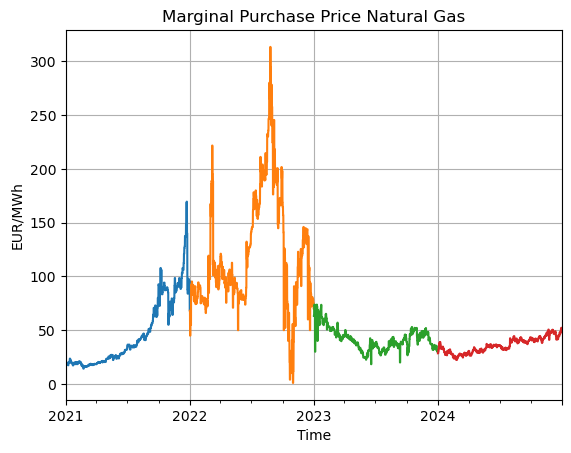

In [16]:

# To add it to your PyPSA network:
# n23.generators_t.weight_carbon = co2_2023.values
grid_emissions = co2_21_24/1e3 # t/MWh
NG_price["MarginalPurchasePriceEUR_MWh"]["2021"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2022"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2023"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2024"].plot()
#elspotprices["SpotPriceEUR"].plot()
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.xlim("2021-01-01", "2024-12-31")
plt.title("Marginal Purchase Price Natural Gas")
plt.grid()


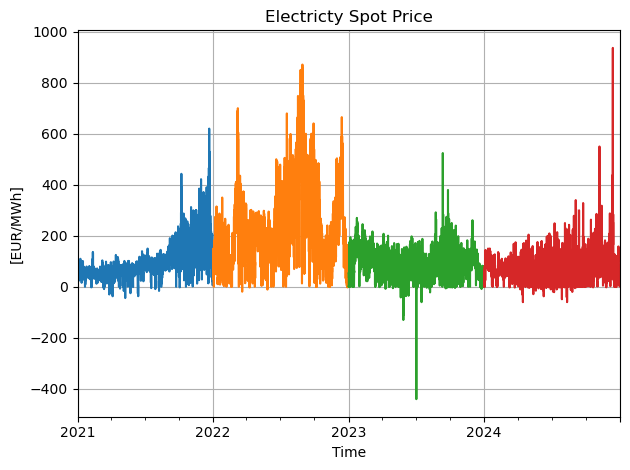

In [17]:
elspotprices["SpotPriceEUR"]["2021"].plot()
elspotprices["SpotPriceEUR"]["2022"].plot()
elspotprices["SpotPriceEUR"]["2023"].plot()
elspotprices["SpotPriceEUR"]["2024"].plot()
plt.ylabel("[EUR/MWh]")
plt.xlabel("Time")
plt.grid()
plt.title("Electricty Spot Price")
#plt.legend(["2021", "2022", "2023", "2024"])
plt.tight_layout()
plt.show()


In [18]:
"Filling Missing Data Values";
grid_emissions["2021":"2024"] = grid_emissions["2021":"2024"].ffill().bfill()
grid_emissions["2021":"2024"].isna().sum()

np.int64(0)

Text(0, 0.5, 'Emissions Intensity [$t_{CO_2}/MWh$]')

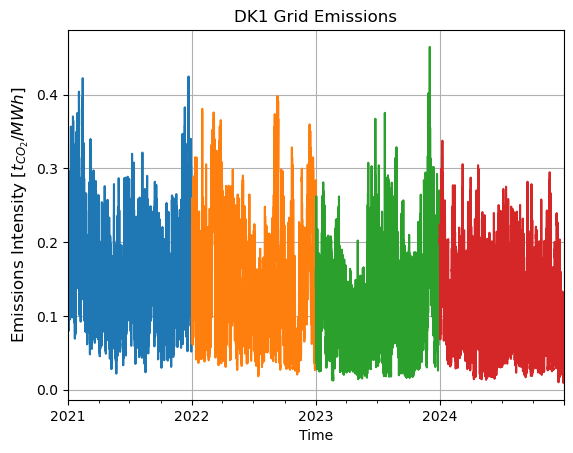

In [19]:
grid_emissions["2021"].plot()
grid_emissions["2022"].plot()
grid_emissions["2023"].plot()
grid_emissions["2024"].plot()
plt.title("DK1 Grid Emissions")
plt.xlabel("Time")
plt.grid()
plt.ylabel(r"Emissions Intensity [$t_{CO_2}/MWh$]", fontsize=12)


Text(0.5, 1.0, 'ACF Spot Prices')

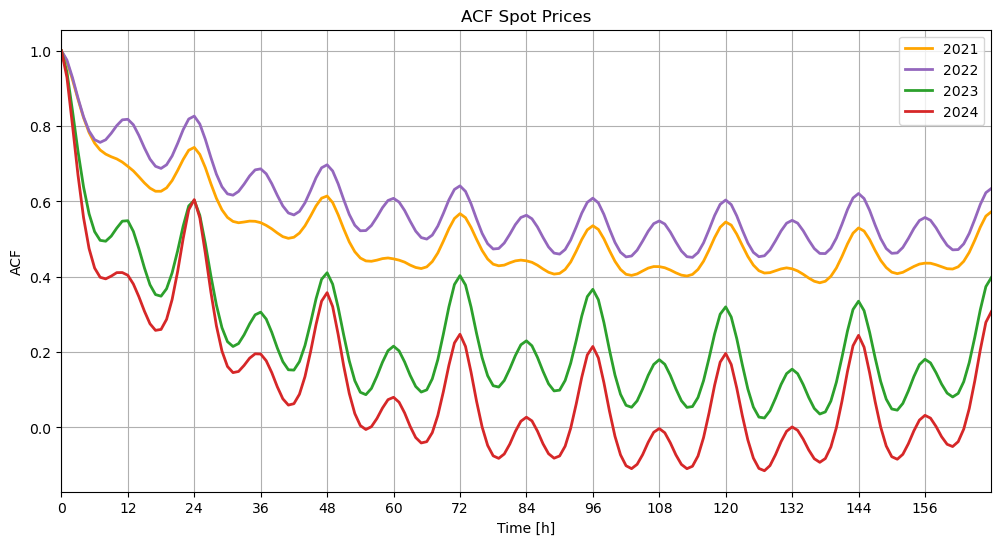

In [34]:

# 1. Calculate the ACF values for a week (168 hours)
nlags = 24*7*1
acf_price21 = acf(elspotprices["SpotPriceEUR"]["2021"], nlags=nlags)
acf_price22 = acf(elspotprices["SpotPriceEUR"]["2022"], nlags = nlags)
acf_price23 = acf(elspotprices["SpotPriceEUR"]["2023"], nlags = nlags)
acf_price24 = acf(elspotprices["SpotPriceEUR"]["2024"], nlags = nlags)
#acf_solar22 = acf(CF_solar["2022"], nlags=nlags)

# 2. Plot using plt.plot() for clarity over long durations
plt.figure(figsize=(12, 6))
plt.grid()
# Plot wind in blue and solar in orange
plt.plot(range(len(acf_price21)), acf_price21, label='2021', color='orange', linewidth=2)
plt.plot(range(len(acf_price22)), acf_price22, label='2022', color='tab:purple', linewidth=2)
plt.plot(range(len(acf_price23)), acf_price23, label='2023', color='tab:green', linewidth=2)
plt.plot(range(len(acf_price24)), acf_price24, label='2024', color='tab:red', linewidth=2)
plt.xlim(0,24*7)
plt.xticks(range(0,24*7,12))
plt.xlabel("Time [h]")
plt.ylabel("ACF")
plt.legend()
plt.title("ACF Spot Prices")


# MGA Scenario + Datacentre

In [205]:
def add_carriers(n):
    # Electricity Carriers
    n.add("Carrier", "onshorewind", color="#235ebc", nice_name="Onshore Wind")
    n.add("Carrier", "solar", color="#f9d002", nice_name="Solar PV")
    n.add("Carrier", "electricity", color="#ffde00")
    
    # Grid Interaction
    n.add("Carrier", "imports", color="#d3d3d3", nice_name="Grid Import")
    n.add("Carrier", "exports", color="#a9a9a9", nice_name="Grid Export")

    # Thermal & Storage
    # Note: 78.4% efficiency logic is usually handled in the Link, 
    # but the carrier helps with labeling.
    n.add("Carrier", "RONDO_store", color="#e6194b", nice_name="RONDO Storage")
    n.add("Carrier", "RONDO_charge", color="#fabebe")
    n.add("Carrier", "RONDO_discharge", color="#911eb4")
    n.add("Carrier", "El_Boiler", color="#f58231", nice_name="Electric Boiler")
    
    # Gas & Biomass
    n.add("Carrier", "gas", color="#525252", nice_name="Natural Gas") 
    n.add("Carrier", "pellets", color="#808000")
    n.add("Carrier", "biomass", unit="t/h", color="#2ca02c")
    
    # Circular Economy & PtX
    n.add("Carrier", "Pyrolysis", color="#3cb44b")
    n.add("Carrier", "methanol", color="#4363d8")
    n.add("Carrier", "CO2", unit="t/h", color="#000000")
    n.add("Carrier", "biochar", color="#469990")

    n.add("Carrier", "biochar_sequestered")
    n.add("Carrier", "methanol")
    n.add("Carrier", "Methanolisation")
    n.add("Carrier", "methane")

    n.add("Carrier", "heat")
    n.add("Carrier", "electricity")

In [206]:
def heat_load(n,P_heat = 5):
    n.add("Load", "Biogas_Heat", carrier = "heat",
        bus = "Heat_MT",
        p_set = P_heat)

def el_load(n,P_el = 2):
    n.add("Load", "Biogas_el", carrier = "electricity",
        bus = "Greenlab",
        p_set = P_el)

In [207]:
def add_battery2(n,P_nom, max_t, cyclic_operation = True):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="Greenlab",  # Use your electricity bus name {EuroWind, Greenlab}
        carrier="battery_storage",
        max_hours= max_t,  # 22 MW * 2 h = 44 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"] + 4 * costs.at["battery storage", "capital_cost"],
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # Discharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_min = 22,
        p_nom_max = 100,
        p_nom_extendable=True,
        cyclic_state_of_charge=cyclic_operation)

In [208]:
def add_skive_generators2(n,s_cf,w_cf):

    # EuroWind Owns These Assets
    n.add("Generator", "Skive_Solar", carrier="solar",
        bus = "Greenlab" , # Greenlab , EuroWind
        capital_cost=costs.at["solar", "capital_cost"],
        #marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu= s_cf, 
        p_nom = 30,
        p_nom_extendable = True,
        p_nom_min = 30,
        p_nom_max = 90)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "Greenlab",
        capital_cost=costs.at["onwind", "capital_cost"],
        #marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu= w_cf,
        p_nom = 54,
        p_nom_extendable = True,
        p_nom_min = 54,
        p_nom_max = 150)

In [209]:
def add_SkyClean_simple(n,CO2tax):  
    n.add("Generator","pellets input",
        bus="pellets",
        carrier="pellets",
        p_nom_extendable=True,
        marginal_cost= 62) #€/MWh (Price of straw pellets 380 €/t

    n.add("Store","pellets store",
     e_initial = (0.12*100)*len(n.snapshots), # MW (avialable pellets from a biogas plant) 
     e_nom = (0.12*100)*len(n.snapshots),
     bus = "pellets",
     carrier = "pellets",
     e_nom_extendable = False,
     e_cyclic = False)
    
    # straw pellets cost from 35 - 82 EUR/ton
    # LHV_pellets = 16 MJ/kg

    n.add("Link", "pyrolysis",
        bus0="pellets",
        bus1="Heat_MT",
        bus2="biochar",
        bus3 = "Greenlab",
        p_nom_extendable=False,
        p_nom=2,
        efficiency = 8.5/20, # MW , 8.2/21.7 , Heat High Temp
        efficiency2 = 9/20, # MW , 10.1/21.7 , Biochar
        efficiency3 = -0.02, # MW, auxillary power (2 %)
        carrier="Pyrolysis",
        capital_cost=costs.at["biochar pyrolysis","capital_cost"],
        #marginal_cost = 62, # EUR/MWh (cost of buying pellets from market)
        ) 

    
    n.add("Link", "biochar sequestration",
        bus0="biochar",
        bus1="biochar sequestration",
        efficiency=1,
        #p_nom = 1, # MW  
        p_nom_extendable = True,
        marginal_cost= -0.313*CO2tax,   #CO2 tax   or -0.164 (tCO2/MWh_pell)?  # -1  * co2_credits #-13.12eur/MWh
        carrier="biochar") 

    n.add("Store", "biochar sequestred",
        bus="biochar sequestration",
        #e_nom = 8e3,
        e_nom_extendable=True,
        e_cyclic=False,
        carrier="biochar_sequestered")

In [210]:
"High Temprature Bus (350)";
def add_TES_rondo2(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        e_nom= e_nom_store, # MWh
        e_nom_extendable=True,
        e_nom_min = e_nom_store,
        e_nom_max = 300,
        e_cyclic=False,
        standing_loss= 1.2/100, # 1.2% per hour
        carrier = "RONDO_store",
        capital_cost=costs.at["Concrete-store", "capital_cost"] )      

    # "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link","El_to_TES_Rondo",
        bus0="Greenlab",
        bus1="TES_Rondo",
        p_nom_extendable=True,
        p_nom_min = p_nom_charge,
        #p_nom_max = p_nom_charge, 
        p_nom = p_nom_charge, # MW
        efficiency=0.98,
        carrier = "RONDO_charge",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    # "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link", "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_MT",
        p_nom = p_nom_discharge,
        p_nom_extendable=True,
        p_nom_min = p_nom_discharge,
        #p_nom_max = p_nom_discharge,
        efficiency=0.90*0.8, # Including Efficency of Heat Exchanger here
        carrier = "RONDO_discharge",
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])

In [211]:
def rondo_constraints(n, snapshots):
    model = n.model
    store_name = "Rondo_Concrete_Heat_Storage"
    charge_link = "El_to_TES_Rondo"
    discharge_link = "TES_Rondo_to_Heat_Bus_Skive"

    # 1. Identify if components are Variables (extendable)
    # Using .index on the xarray variable is the most reliable way to check membership
    is_store_var = "Store-e_nom" in model.variables and store_name in model.variables["Store-e_nom"].labels.values
    is_charge_var = "Link-p_nom" in model.variables and charge_link in model.variables["Link-p_nom"].labels.values
    is_discharge_var = "Link-p_nom" in model.variables and discharge_link in model.variables["Link-p_nom"].labels.values

    # 2. Get Capacity (e_nom)
    e_nom = model.variables["Store-e_nom"].loc[store_name] if is_store_var else n.stores.at[store_name, "e_nom"]
    
    # 3. Add Charge Constraint (24% Ratio)
    if is_store_var or is_charge_var:
        p_nom_charge = model.variables["Link-p_nom"].loc[charge_link] if is_charge_var else n.links.at[charge_link, "p_nom"]
        model.add_constraints(p_nom_charge - 0.24 * e_nom == 0, name="Rondo_charge_ratio")

    # 4. Add Discharge Constraint (7% Ratio)
    if is_store_var or is_discharge_var:
        p_nom_discharge = model.variables["Link-p_nom"].loc[discharge_link] if is_discharge_var else n.links.at[discharge_link, "p_nom"]
        model.add_constraints(p_nom_discharge - 0.07 * e_nom == 0, name="Rondo_discharge_ratio")

In [212]:
def  add_electric_boiler2(n):
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "Greenlab",
        bus1="Heat_MT",
        #p_nom = 10, # MW,
        p_nom_extendable = True,
        p_nom = 10,
        p_nom_min = 10,
        #p_nom_max = 10,
        efficiency=0.95, # 0.9
        carrier = "El_Boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"],
        #marginal_cost = costs.at["electric boiler steam","marginal_cost"]
        )

In [213]:
def add_NG_boiler2(n,CO2tax, NG_price):
     n.add("Generator",
        "NG grid",
        bus="NG",
        carrier="gas",
        p_nom = 6,
        p_nom_min = 6,
        marginal_cost = NG_price + 0.202*CO2tax + 1.007, #0.206  tCO2/MWh *  80EUR/tC02 + VOM 1.007EUR/MWh
        p_nom_extendable=True,)

     n.add("Link","NG boiler",
        bus0="NG",
        bus1="Heat_MT",
        carrier = "NG_boiler",
        capital_cost = costs.at["decentral gas boiler","capital_cost"],
        efficiency=0.9, # 0.98
        p_nom=6,
        p_nom_min = 6,
        p_nom_extendable=True,) 

- currently there is 84 MW {Generation}
- assuming currently that Generation = Import
- Transformer Stations = Gen[MW] + Imports[MW]
- 200 >= P_gen + P_import

In [214]:
def add_grid2(n, price_import, price_export, grid_emissions, CO2tax):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
          bus="Grid_Import",
          p_nom_extendable=True,
          p_nom = 84, # GCP limit
          p_nom_min = 84,
          p_nom_max = 120,
          efficiency=1.0,
          marginal_cost=0,
          capital_cost=0.0,
          carrier="imports")

    n.add("Link", "Imports",
          bus0="Grid_Import",
          bus1="Greenlab",   # [EuroWind or Greenlab]
          p_nom=84,
          p_nom_min = 84,
          p_nom_max = 120,
          p_nom_extendable=True,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="imports",
          capital_cost = costs.at["electricity grid connection", "capital_cost"],
          marginal_cost= price_import + grid_emissions*CO2tax)

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          #e_nom = 130e3, # MWh 
          e_0 = 0,
          capital_cost=0.0,
          standing_loss=0.0,
          carrier="exports")

    n.add("Link", "Exports",
          bus0="Greenlab",   # [EuroWind or Greenlab]
          bus1="Grid_Export",
          p_nom=84,
          p_nom_min = 84,
          p_nom_max = 120,
          p_nom_extendable=True,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="exports",
          marginal_cost=price_export)

- Imports = Exports

In [215]:
def grid_capacity_constraint(n, snapshots):
    """
    Forces the nominal capacity of the Import link to equal the Export link.
    """
    # 1. Check if Link-p_nom is a variable (extendable)
    if "Link-p_nom" in n.model.variables:
        # 2. Use .loc to select by label without needing the dimension name
        # This is exactly how your rondo_constraints handles e_nom
        import_p_nom = n.model.variables["Link-p_nom"].loc["Imports"]
        export_p_nom = n.model.variables["Link-p_nom"].loc["Exports"]
        
        # 3. Add the constraint
        n.model.add_constraints(
            import_p_nom - export_p_nom == 0, 
            name="Link-grid_equity"
        )

In [216]:
def skive_generation_grid_limit(n, snapshots):
    """
    Limits combined Wind + Solar capacity to the size of the Export Link.
    Constraint: Skive_Solar.p_nom + Skive_Onshore_Wind.p_nom <= Exports.p_nom
    """
    model = n.model
    
    # Ensure all necessary variables are in the optimization model
    if "Generator-p_nom" in model.variables and "Link-p_nom" in model.variables:
        
        solar_p = model.variables["Generator-p_nom"].loc["Skive_Solar"]
        wind_p = model.variables["Generator-p_nom"].loc["Skive_Onshore_Wind"]
        import_p = model.variables["Link-p_nom"].loc["Imports"]
        export_p = model.variables["Link-p_nom"].loc["Exports"]

        # This allows the solver to build UP TO the export capacity
        model.add_constraints(
            solar_p + wind_p - export_p <= 0, 
            name="Grid Symmetry")

       # To this (if you want the 200MW total site limit):
        #model.add_constraints(solar_p + wind_p + import_p <= 200
        #, name="Substation Cap")

In [217]:
# --- NEW: Combined Extra Functionality ---
def combined_constraints(n, snapshots):
        # 1. Run your existing Rondo constraints
        rondo_constraints(n, snapshots)
        # 2. Run the new grid capacity constraint
        grid_capacity_constraint(n, snapshots)
        # 3. Generation + Grid Limit
        skive_generation_grid_limit(n, snapshots)

In [218]:
def build_network_simple_w_datacentre(P_el_extra, P_heat, P_el, CO2_tax, grid_emissions, p_import, p_export, NG_price, horizon, overlap):
    n = pypsa.Network()
    n.set_snapshots(NG_price.index)

    # Align time-series data
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_imp = p_import.loc[n.snapshots].values
    p_exp = p_export.loc[n.snapshots].values
    grid_ems = grid_emissions.reindex(n.snapshots).ffill().values
    
    add_carriers(n)

    # Electricity & Generators
    n.add("Bus", "Greenlab", carrier="electricity")
    add_skive_generators2(n, s_cf, w_cf)
    add_battery2(n, P_nom=22, max_t=2, cyclic_operation=False)

    # Grid Connections
    n.add("Bus", "Grid_Import", carrier="imports")
    n.add("Bus", "Grid_Export", carrier="exports")
    add_grid2(n, price_import=p_imp, price_export=p_exp, grid_emissions=grid_ems, CO2tax=CO2_tax)

    # Heat & Boilers
    n.add("Bus", "Heat_MT", carrier="heat")
    add_electric_boiler2(n)

    # RONDO Storage
    n.add("Bus", "TES_Rondo", carrier="RONDO_store")
    # Make sure the name inside this helper function matches "Rondo_Concrete_Heat_Storage"
    add_TES_rondo2(n, e_nom_store=100, p_nom_charge=24, p_nom_discharge=7)

    # Biogas/SkyClean Section
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "biochar", carrier="biochar")
    n.add("Bus", "biochar sequestration", carrier="biochar_sequestered")
    add_SkyClean_simple(n, CO2tax=CO2_tax)

    # Natural Gas
    n.add("Bus", "NG", carrier="gas")
    add_NG_boiler2(n, CO2tax=CO2_tax, NG_price=NG_price)

    # Loads
    heat_load(n, P_heat=P_heat)
    el_load(n, P_el=P_el)

    n.add("Load", "Datacentre",
          bus="Greenlab",
          p_set=P_el_extra,
          carrier="electricity")

    # --- Solving Section ---
    if horizon is not None:
        # Rolling Horizon Optimization
        n.optimize.optimize_with_rolling_horizon(
            assign_all_duals=True,
            solver_name="gurobi", 
            horizon=horizon, 
            overlap=overlap,
            extra_functionality=combined_constraints # Pass function reference
        )
    else:
        # Full Year Optimization
        n.optimize(
            assign_all_duals=True,
            solver_name="gurobi",
            extra_functionality=combined_constraints# Pass function reference
        )

    return n

In [219]:
n21_w_datacentre = build_network_simple_w_datacentre(P_el_extra = 100,P_heat = 5, P_el = 2,CO2_tax = 80, grid_emissions = grid_emissions["2021"],p_import = import_price21, p_export = export_price21, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2021"], horizon = None, overlap = None)

Index(['NG boiler'], dtype='object', name='name')
Index(['Skive_Battery'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 19.29it/s]
INFO:linopy.io: Writing time: 4.51s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 14688 iterations and 5.75 seconds (2.79 work units)


INFO:gurobipy:Solved in 14688 iterations and 5.75 seconds (2.79 work units)


Optimal objective  9.425878946e+07


INFO:gurobipy:Optimal objective  9.425878946e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210113 primals, 472741 duals
Objective: 9.43e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Grid Symmetry were not assigned to the network.


In [227]:
n21_w_datacentre.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Grid Import                     120.0                84.0   
            Natural Gas                       6.0                 6.0   
            Onshore Wind                     90.0                54.0   
            Solar PV                         30.0                30.0   
Link        Electric Boiler                  10.0                10.0   
            Grid Export                     120.0                84.0   
            Grid Import                     120.0                84.0   
            NG_boiler                         6.0                 6.0   
            Pyrolysis                         2.0                 2.0   
            RONDO_charge                     24.0                24.0   
            RONDO_discharge                   7.0                 7.0   
            biochar                           0.9                 0.0   
Load        electricity                       0.0                 0.0   
            heat                              0.0                 0.0   
StorageUnit battery_storage                  22.0                22.0   
Store       RONDO Storage                   100.0               100.0   
            biochar_sequestered            7878.6                 0.0   
            pellets                      105048.0            105048.0   

                                       Supply    Withdrawal  Energy Balance  \
Generator   Grid Import          702731.72119       0.00000    702731.72119   
            Natural Gas           35700.00257       0.00000     35700.00257   
            Onshore Wind         190315.19464       0.00000    190315.19464   
            Solar PV              30548.46600       0.00000     30548.46600   
Link        Electric Boiler           0.00000    2282.25169     -2282.25169   
            Grid Export               0.00000       0.00000         0.00000   
            Grid Import               0.00000  702731.72119   -702731.72119   
            NG_boiler                 0.00000   35700.00257    -35700.00257   
            Pyrolysis                 0.00000   17508.00000    -17508.00000   
            RONDO_charge              0.00000    3251.66426     -3251.66426   
            RONDO_discharge           0.00000    2820.77581     -2820.77581   
            biochar                   0.00000    7878.60000     -7878.60000   
Load        electricity               0.00000  892908.00000   -892908.00000   
            heat                      0.00000   43770.00000    -43770.00000   
StorageUnit battery_storage       23592.96866   27314.32291     -3721.35425   
Store       RONDO Storage          2820.77581    3186.63098      -365.85516   
            biochar_sequestered       0.00000    7878.60000     -7878.60000   
            pellets               17508.00000       0.00000     17508.00000   

                                Transmission  Capacity Factor   Curtailment  \
Generator   Grid Import                  0.0         0.668962  347748.27881   
            Natural Gas                  0.0         0.679690   16823.99743   
            Onshore Wind                 0.0         0.241560     426.48419   
            Solar PV                     0.0         0.116322       0.00000   
Link        Electric Boiler              0.0         0.026071       0.00000   
            Grid Export                  0.0         0.000000       0.00000   
            Grid Import                  0.0         0.668962       0.00000   
            NG_boiler                    0.0         0.679690       0.00000   
            Pyrolysis                    0.0         1.000000       0.00000   
            RONDO_charge                 0.0         0.015477       0.00000   
            RONDO_discharge              0.0         0.046033       0.00000   
            biochar                      0.0         1.000000       0.00000   
Load        electricity                  0.0              NaN       0.00000   
            heat                     

In [226]:
n24_w_datacentre.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Grid Import                     120.0                84.0   
            Natural Gas                       6.0                 6.0   
            Onshore Wind                     90.0                54.0   
            Solar PV                         30.0                30.0   
Link        Electric Boiler                  10.0                10.0   
            Grid Export                     120.0                84.0   
            Grid Import                     120.0                84.0   
            NG_boiler                         6.0                 6.0   
            Pyrolysis                         2.0                 2.0   
            RONDO_charge                     24.0                24.0   
            RONDO_discharge                   7.0                 7.0   
            biochar                           0.9                 0.0   
Load        electricity                       0.0                 0.0   
            heat                              0.0                 0.0   
StorageUnit battery_storage                  22.0                22.0   
Store       RONDO Storage                   100.0               100.0   
            biochar_sequestered            7905.6                 0.0   
            pellets                      105408.0            105408.0   

                                       Supply    Withdrawal  Energy Balance  \
Generator   Grid Import          690837.53918       0.00000    690837.53918   
            Natural Gas           28368.91172       0.00000     28368.91172   
            Onshore Wind         215059.37774       0.00000    215059.37774   
            Solar PV              29221.93200       0.00000     29221.93200   
Link        Electric Boiler           0.00000    6106.30709     -6106.30709   
            Grid Export               0.00000       0.00000         0.00000   
            Grid Import               0.00000  690837.53918   -690837.53918   
            NG_boiler                 0.00000   28368.91172    -28368.91172   
            Pyrolysis                 0.00000   17568.00000    -17568.00000   
            RONDO_charge              0.00000    8139.90236     -8139.90236   
            RONDO_discharge           0.00000    7111.92738     -7111.92738   
            biochar                   0.00000    7905.60000     -7905.60000   
Load        electricity               0.00000  895968.00000   -895968.00000   
            heat                      0.00000   43920.00000    -43920.00000   
StorageUnit battery_storage       24286.24074   28114.39405     -3828.15330   
Store       RONDO Storage          7111.92738    7977.10431      -865.17693   
            biochar_sequestered       0.00000    7905.60000     -7905.60000   
            pellets               17568.00000       0.00000     17568.00000   

                                Transmission  Capacity Factor   Curtailment  \
Generator   Grid Import                  0.0         0.655394  363242.46082   
            Natural Gas                  0.0         0.538268   24335.08828   
            Onshore Wind                 0.0         0.272034     452.08253   
            Solar PV                     0.0         0.110891       0.00000   
Link        Electric Boiler              0.0         0.069516       0.00000   
            Grid Export                  0.0         0.000000       0.00000   
            Grid Import                  0.0         0.655394       0.00000   
            NG_boiler                    0.0         0.538268       0.00000   
            Pyrolysis                    0.0         1.000000       0.00000   
            RONDO_charge                 0.0         0.038611       0.00000   
            RONDO_discharge              0.0         0.115664       0.00000   
            biochar                      0.0         1.000000       0.00000   
Load        electricity                  0.0              NaN       0.00000   
            heat                     

In [221]:
n24_w_datacentre = build_network_simple_w_datacentre(P_el_extra = 100,P_heat = 5, P_el = 2,CO2_tax = 80, grid_emissions = grid_emissions["2024"],p_import = import_price24, p_export = export_price24, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2024"], horizon = None, overlap = None)

Index(['NG boiler'], dtype='object', name='name')
Index(['Skive_Battery'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 19.03it/s]
INFO:linopy.io: Writing time: 4.55s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 13575 iterations and 6.87 seconds (3.41 work units)


INFO:gurobipy:Solved in 13575 iterations and 6.87 seconds (3.41 work units)


Optimal objective  7.724120125e+07


INFO:gurobipy:Optimal objective  7.724120125e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210833 primals, 474361 duals
Objective: 7.72e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Grid Symmetry were not assigned to the network.


(70.0, 160.0)

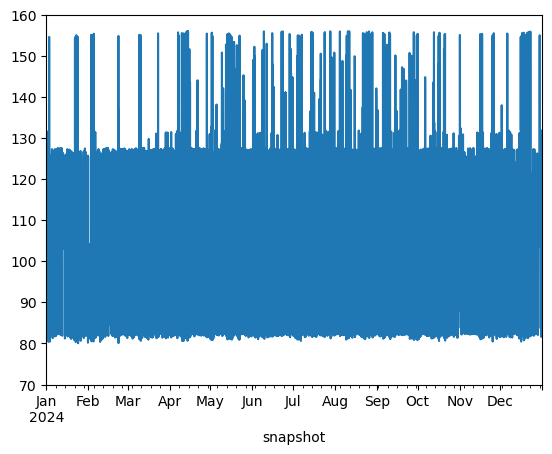

In [229]:
(n24_w_datacentre.links_t.p0["Imports"] + n24_w_datacentre.generators_t.p["Skive_Solar"] + n24_w_datacentre.generators_t.p["Skive_Onshore_Wind"]).plot()
plt.ylim(70,160)

<Axes: xlabel='snapshot'>

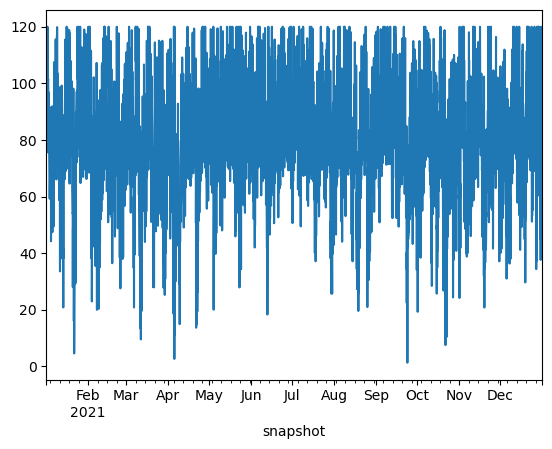

In [230]:
n21_w_datacentre.links_t.p0["Imports"].plot()

<Axes: xlabel='snapshot'>

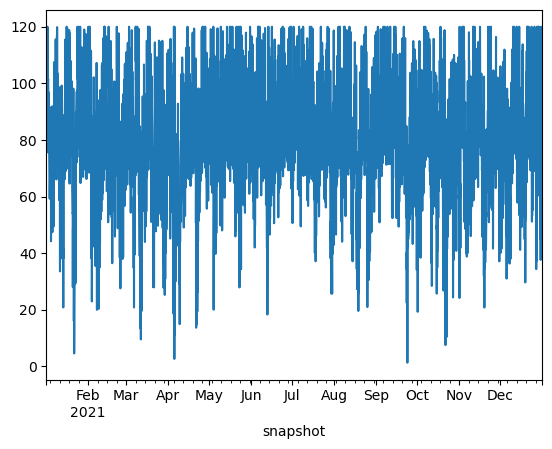

In [233]:
n21_w_datacentre.links_t.p0["Imports"].plot()

In [225]:
n24_w_datacentre.links

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt,bus3,efficiency3,bus2,efficiency2
name,,,,,,,,,,,,,,,,,,,,,
Imports,Grid_Import,Greenlab,,imports,0.970,True,0,inf,84.0,0.0,...,0,NaN,NaN,1.0,1.0,120.0,,1.00,,1.00
Exports,Greenlab,Grid_Export,,exports,0.970,True,0,inf,84.0,0.0,...,0,NaN,NaN,1.0,1.0,120.0,,1.00,,1.00
Boiler_Skive,Greenlab,Heat_MT,,El_Boiler,0.950,True,0,inf,10.0,0.0,...,0,NaN,NaN,1.0,1.0,10.0,,1.00,,1.00
El_to_TES_Rondo,Greenlab,TES_Rondo,,RONDO_charge,0.980,True,0,inf,24.0,0.0,...,0,NaN,NaN,1.0,1.0,24.0,,1.00,,1.00
TES_Rondo_to_Heat_Bus_Skive,TES_Rondo,Heat_MT,,RONDO_discharge,0.720,True,0,inf,7.0,0.0,...,0,NaN,NaN,1.0,1.0,7.0,,1.00,,1.00
pyrolysis,pellets,Heat_MT,,Pyrolysis,0.425,True,0,inf,2.0,0.0,...,0,NaN,NaN,1.0,1.0,2.0,Greenlab,-0.02,biochar,0.45
biochar sequestration,biochar,biochar sequestration,,biochar,1.000,True,0,inf,0.0,0.0,...,0,NaN,NaN,1.0,1.0,0.9,,1.00,,1.00
NG boiler,NG,Heat_MT,,NG_boiler,0.900,True,0,inf,6.0,0.0,...,0,NaN,NaN,1.0,1.0,6.0,,1.00,,1.00


# MGA

In [95]:
from pypsa.optimization.mga import generate_directions_random
from scipy.spatial import ConvexHull, convex_hull_plot_2d
from matplotlib.collections import LineCollection

In [234]:

def run_mga_multi_dimensions(network, slack, num_directions=10, seed=0):
    """
    Explores the near-optimal space in multiple random directions 
    to map the feasibility 'kite'.
    """
    # 1. Safely unlock the solver model
    model = getattr(network, "model", None)
    if model is not None:
        model.solver_model = None
    
    # 2. Prepare local copy
    n_temp = network.copy()
    
    # 3. Define the search dimensions (Decision Variables)
    dimensions = {
        "wind": {"Generator": {"p_nom": {"Skive_Onshore_Wind": 1}}},
        "solar": {"Generator": {"p_nom": {"Skive_Solar": 1}}},
        "rondo": {"Store": {"e_nom": {"Rondo_Concrete_Heat_Storage": 1}}},
        "battery": {"StorageUnit": {"p_nom": {"Skive_Battery": 1}}},
        #"grid": {"links": {"p_nom": {"Imports": 1}}},
        #"NG boiler": {"links": {"p_nom": {"NG boiler": 0}}},
        #"RONDO discharger": {"links": {"p_nom": {"TES_Rondo_to_Heat_Bus_Skive": 0}}},
        #"El boiler": {"links": {"p_nom": {"Boiler_Skive": 0}}},
    }
    
    # 4. Generate random search vectors
    #directions = generate_directions_random(dimensions.keys(), num_directions, seed=seed)
    directions = pypsa.optimization.mga.generate_directions_halton(dimensions.keys(), num_directions, seed=0)
    
    # 5. Solve in parallel
    print(f"Solving MGA in {num_directions} directions | Slack: {slack*100}%")

    # This returns the directions used and the resulting coordinate points
    dirs, pts = n_temp.optimize.optimize_mga_in_multiple_directions(
        dimensions=dimensions,
        directions=directions,
        slack=slack,
        solver_name="gurobi",
        max_parallel=8 # Adjust based on your CPU cores
    )
    
    return pts

In [ ]:
# 1. Run the multi-directional search
n21_mga = run_mga_multi_dimensions(n21_w_datacentre, slack=0.01, num_directions=20)
# 2. Display the first few points
print(n21_mga)

Solving MGA in 20 directions | Slack: 1.0%


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\Pulin\AppData\Local\Temp\tmp7_e2qb4y.nc contains: generators, buses, storage_units, stores, loads, carriers, sub_networks, links


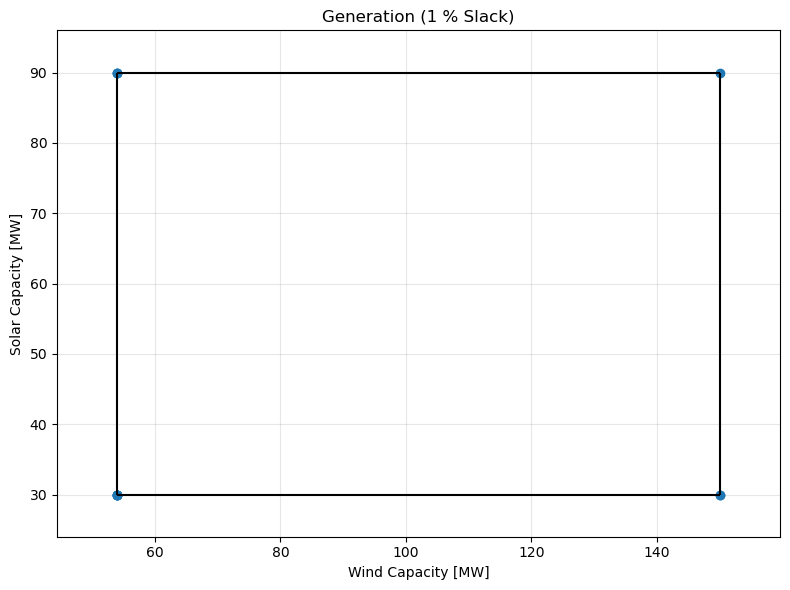

In [237]:

# Create a figure for the Storage trade-off
fig, ax = plt.subplots(figsize=(8, 6))

# Extract the storage coordinates
# Note: Ensure these column names match your pts dataframe (e.g., 'rondo' and 'battery')
pts_storage = n21_mga[['wind', 'solar']]
hull_storage = ConvexHull(pts_storage)

# Plot the convex hull
convex_hull_plot_2d(hull_storage, ax)

# Style the plot
ax.set_xlabel("Wind Capacity [MW]")
ax.set_ylabel("Solar Capacity [MW]")
ax.set_title("Generation (1 % Slack)")
ax.grid(True, alpha=0.3)

# Add a marker for the baseline (if you have the values)
# ax.scatter(opt_rondo, opt_battery, color='red', marker='*', s=200, label='Optimal')
plt.tight_layout()
plt.show()

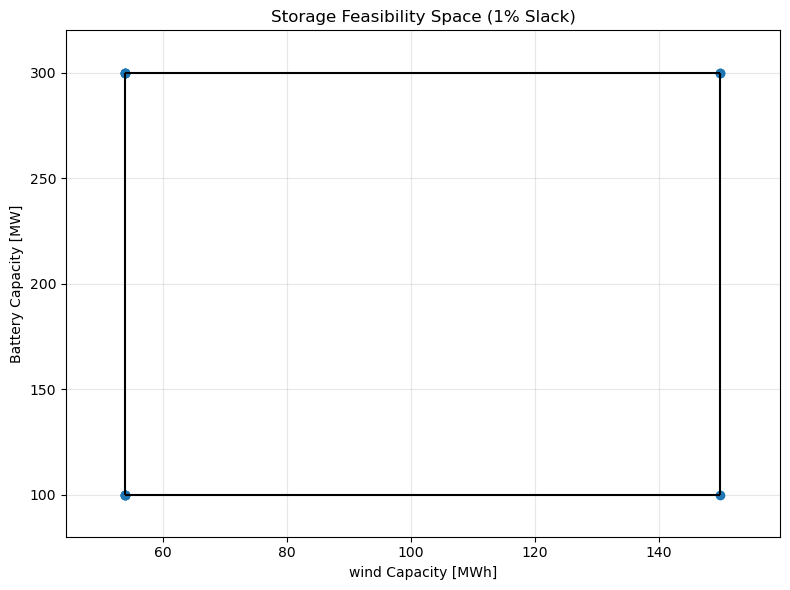

In [238]:

# Create a figure for the Storage trade-off
fig, ax = plt.subplots(figsize=(8, 6))

# Extract the storage coordinates
# Note: Ensure these column names match your pts dataframe (e.g., 'rondo' and 'battery')
pts_storage = n21_mga[['wind', 'rondo']]
hull_storage = ConvexHull(pts_storage)

# Plot the convex hull
convex_hull_plot_2d(hull_storage, ax)

# Style the plot
ax.set_xlabel("wind Capacity [MWh]")
ax.set_ylabel("Battery Capacity [MW]")
ax.set_title("Storage Feasibility Space (1% Slack)")
ax.grid(True, alpha=0.3)

# Add a marker for the baseline (if you have the values)
# ax.scatter(opt_rondo, opt_battery, color='red', marker='*', s=200, label='Optimal')
plt.tight_layout()
plt.show()

In [153]:
# 1. Run the multi-directional search
n24_mga = run_mga_multi_dimensions(n24_w_datacentre, slack=0.01, num_directions=20)
# 2. Display the first few points
print(n24_mga.head())

Solving MGA in 20 directions | Slack: 1.0%


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\Pulin\AppData\Local\Temp\tmpr2f4fblp.nc contains: generators, buses, storage_units, stores, loads, carriers, sub_networks, links


         wind  solar  rondo     battery
0  150.000000   30.0  100.0  100.000000
1   54.000000   90.0  300.0   38.950260
2   55.173669   30.0  300.0   22.000000
3   98.596958   30.0  300.0  100.000000
4   73.190442   90.0  100.0   88.381164


In [156]:
n24_mga

,wind,solar,rondo,battery
0,150.000000,30.0,100.0,100.000000
1,54.000000,90.0,300.0,38.950260
2,55.173669,30.0,300.0,22.000000
3,98.596958,30.0,300.0,100.000000
4,73.190442,90.0,100.0,88.381164
5,54.000000,30.0,100.0,22.000000
6,150.000000,30.0,300.0,22.000000
7,150.000000,90.0,100.0,22.000000
8,54.000000,30.0,100.0,22.000000
9,150.000000,30.0,100.0,100.000000


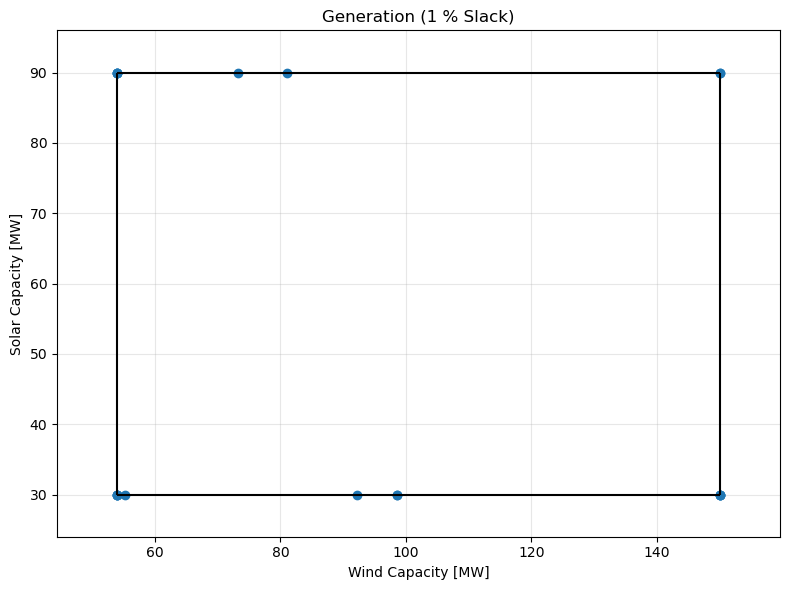

In [154]:
# Create a figure for the Storage trade-off
fig, ax = plt.subplots(figsize=(8, 6))

# Extract the storage coordinates
# Note: Ensure these column names match your pts dataframe (e.g., 'rondo' and 'battery')
pts_storage = n24_mga[['wind', 'solar']]
hull_storage = ConvexHull(pts_storage)

# Plot the convex hull
convex_hull_plot_2d(hull_storage, ax)

# Style the plot
ax.set_xlabel("Wind Capacity [MW]")
ax.set_ylabel("Solar Capacity [MW]")
ax.set_title("Generation (1 % Slack)")
ax.grid(True, alpha=0.3)

# Add a marker for the baseline (if you have the values)
# ax.scatter(opt_rondo, opt_battery, color='red', marker='*', s=200, label='Optimal')
plt.tight_layout()
plt.show()